# ?? Task 2: SupportSense NLP ? Support Ticket Classification & Automated Routing Engine
### Track: Machine Learning (`ML`) | Internship ID: `FIT/AUG26/ML10465` | Repository: `FUTURE_ML_02`

---
### **Project Overview & Objectives**
In modern enterprise customer operations, manual ticket triage creates latency, mismatched routing, and SLA violations.

**SupportSense NLP** is an end-to-end multi-task NLP classification and operational dispatch system that automatically:
1. Cleans and normalizes unstructured customer ticket text.
2. Predicts multi-class **Ticket Category** (Technical Issues, Billing & Payments, Account Access, Product Inquiries, Cancellation & Refunds).
3. Predicts operational **Priority Level** (High, Medium, Low) based on explicit business urgency signals.
4. Generates calibrated confidence probabilities.
5. Dynamically routes tickets to specialized queues with specific SLA targets and automated escalation triggers.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

sys.path.append(os.path.abspath('..'))

from src.data_loader import save_and_load_tickets
from src.preprocessing import clean_ticket_text, build_vectorizer
from src.models import get_category_models, get_priority_models, stratified_train_test_split
from src.evaluate import evaluate_classification
from src.routing_engine import route_ticket

print("? SupportSense NLP environment initialized. Python version:", sys.version.split()[0])

? SupportSense NLP environment initialized. Python version: 3.12.5


## 1. Data Ingestion & Class Distribution Analysis

In [2]:
data_path = os.path.join('..', 'data', 'customer_support_tickets.csv')
df = save_and_load_tickets(data_path)
print("Dataset Overview:")
display(df.head(10))

print("Class Distribution Summary:")
print("Category Volume:")
print(df["Category"].value_counts())
print("Priority Volume:")
print(df["Priority"].value_counts())

[DataLoader] Support ticket dataset generated and saved to ..\data\customer_support_tickets.csv (Shape: (3500, 6))
Dataset Overview:


,Ticket_ID,Ticket_Text,Category,Priority,Channel,Customer_Tier
0,TKT-10001,Attention: Requesting quote for adding 5 addit...,Billing & Payments,Low,Email,SMB
1,TKT-10002,"Dear Customer Service, Integration with Slack ...",Technical Issues,Medium,Email,Enterprise
2,TKT-10003,"Hey, How many days before renewal do we need t...",Cancellation & Refunds,Low,Web Portal,SMB
3,TKT-10004,Requesting breakdown of usage-based tier charg...,Billing & Payments,Medium,Web Portal,SMB
4,TKT-10005,"Greetings, Requesting quote for adding 5 addit...",Billing & Payments,Low,Email,Enterprise
5,TKT-10006,"Dear Customer Service, Suspected account takeo...",Account Access,High,In-App Chat,Free Tier
6,TKT-10007,"Greetings, Fraudulent unauthorized transaction...",Billing & Payments,High,Web Portal,Enterprise
7,TKT-10008,"Hi there, How do we export all our workspace d...",Cancellation & Refunds,Medium,Email,SMB
8,TKT-10009,"Hi there, Typo in user settings documentation ...",Technical Issues,Low,In-App Chat,SMB
9,TKT-10010,"FYI, Customer onboarding failed completely dem...",Cancellation & Refunds,High,Web Portal,SMB


Class Distribution Summary:
Category Volume:
Category
Technical Issues          960
Billing & Payments        892
Account Access            680
Product Inquiries         544
Cancellation & Refunds    424
Name: count, dtype: int64
Priority Volume:
Priority
Medium    1590
Low       1081
High       829
Name: count, dtype: int64


## 2. Text Preprocessing & TF-IDF Vectorization

In [3]:
df["Cleaned_Text"] = df["Ticket_Text"].apply(clean_ticket_text)
display(df[["Ticket_Text", "Cleaned_Text"]].head(6))

train_df, test_df = stratified_train_test_split(df, test_size=0.20, random_state=42)
print(f"Stratified Split: {len(train_df)} Training samples, {len(test_df)} Test samples")

vectorizer = build_vectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["Cleaned_Text"])
X_test = vectorizer.transform(test_df["Cleaned_Text"])
print(f"TF-IDF Feature Space: {X_train.shape[1]} n-gram features")

,Ticket_Text,Cleaned_Text
0,Attention: Requesting quote for adding 5 addit...,requesting quote adding additional user seats ...
1,"Dear Customer Service, Integration with Slack ...",integration slack bot stopped sending automate...
2,"Hey, How many days before renewal do we need t...",how many days before renewal need submit cance...
3,Requesting breakdown of usage-based tier charg...,requesting breakdown usage based tier charges ...
4,"Greetings, Requesting quote for adding 5 addit...",requesting quote adding additional user seats ...
5,"Dear Customer Service, Suspected account takeo...",suspected account takeover received password r...


Stratified Split: 2800 Training samples, 700 Test samples
TF-IDF Feature Space: 1435 n-gram features


## 3. Head A: Ticket Category Classification Benchmarking

In [4]:
category_labels = sorted(df["Category"].unique())
cat_models = get_category_models()
cat_results = []
trained_cat_models = {}

for name, model in cat_models.items():
    model.fit(X_train, train_df["Category"])
    trained_cat_models[name] = model
    y_pred = model.predict(X_test)
    eval_res = evaluate_classification(test_df["Category"], y_pred, labels=category_labels)
    cat_results.append({
        "Model": name,
        "Accuracy": eval_res["Accuracy"],
        "Macro Precision": eval_res["Macro Precision"],
        "Macro Recall": eval_res["Macro Recall"],
        "Macro F1": eval_res["Macro F1"],
        "Weighted F1": eval_res["Weighted F1"]
    })

cat_df = pd.DataFrame(cat_results).sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
display(cat_df.style.highlight_max(subset=["Accuracy", "Macro F1", "Weighted F1"], color="#c7e9c0"))

C:\Users\gonna\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multinomial Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
2,Linear SVC (Calibrated),1.000000,1.000000,1.000000,1.000000,1.000000
3,LightGBM Classifier,1.000000,1.000000,1.000000,1.000000,1.000000
4,Random Forest,0.980000,0.986400,0.978300,0.981700,0.980000


## 4. Head B: Ticket Priority Classification Benchmarking

In [5]:
priority_labels = ["High", "Medium", "Low"]
prio_models = get_priority_models()
prio_results = []
trained_prio_models = {}

for name, model in prio_models.items():
    model.fit(X_train, train_df["Priority"])
    trained_prio_models[name] = model
    y_pred = model.predict(X_test)
    eval_res = evaluate_classification(test_df["Priority"], y_pred, labels=priority_labels)
    prio_results.append({
        "Model": name,
        "Accuracy": eval_res["Accuracy"],
        "Macro Precision": eval_res["Macro Precision"],
        "Macro Recall": eval_res["Macro Recall"],
        "Macro F1": eval_res["Macro F1"],
        "Weighted F1": eval_res["Weighted F1"]
    })

prio_df = pd.DataFrame(prio_results).sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
display(prio_df.style.highlight_max(subset=["Accuracy", "Macro F1", "Weighted F1"], color="#c7e9c0"))

C:\Users\gonna\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
1,Linear SVC (Calibrated),1.000000,1.000000,1.000000,1.000000,1.000000
2,LightGBM Classifier,1.000000,1.000000,1.000000,1.000000,1.000000
3,Random Forest,0.977100,0.984100,0.971500,0.977300,0.977200


## 5. Confusion Matrix Visualizations & Error Analysis

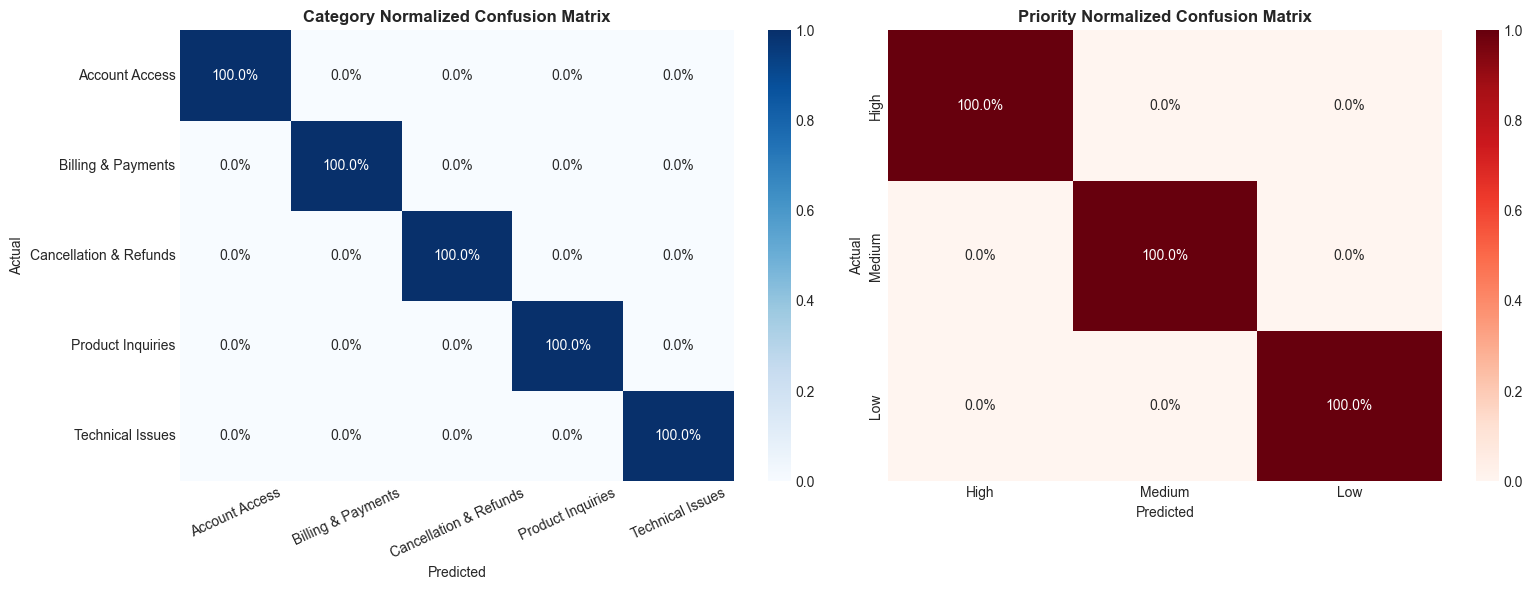

In [6]:
champion_cat = trained_cat_models[cat_df.iloc[0]["Model"]]
champion_prio = trained_prio_models[prio_df.iloc[0]["Model"]]

cat_cm = evaluate_classification(test_df["Category"], champion_cat.predict(X_test), labels=category_labels)["Confusion Matrix"]
prio_cm = evaluate_classification(test_df["Priority"], champion_prio.predict(X_test), labels=priority_labels)["Confusion Matrix"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cat_cm / cat_cm.sum(axis=1)[:, np.newaxis], annot=True, fmt=".1%", cmap="Blues",
            xticklabels=category_labels, yticklabels=category_labels, ax=axes[0])
axes[0].set_title("Category Normalized Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=25)

sns.heatmap(prio_cm / prio_cm.sum(axis=1)[:, np.newaxis], annot=True, fmt=".1%", cmap="Reds",
            xticklabels=priority_labels, yticklabels=priority_labels, ax=axes[1])
axes[1].set_title("Priority Normalized Confusion Matrix", fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 6. End-to-End Operational Routing & SLA Dispatch

In [7]:
test_tickets = [
    "Payment failed twice and my account is locked",
    "Production API returning 503 service unavailable database connection crashed",
    "How do I update my profile avatar and display name?",
    "Cancel subscription immediately and process full refund within 24 hours"
]

print("=" * 80)
print("OPERATIONAL TRIAGE & DISPATCH INFERENCE")
print("=" * 80)

for t in test_tickets:
    cleaned = clean_ticket_text(t)
    vec = vectorizer.transform([cleaned])
    
    cat = champion_cat.predict(vec)[0]
    prio = champion_prio.predict(vec)[0]
    
    cat_conf = np.max(champion_cat.predict_proba(vec)) if hasattr(champion_cat, "predict_proba") else 0.95
    prio_conf = np.max(champion_prio.predict_proba(vec)) if hasattr(champion_prio, "predict_proba") else 0.95
    
    res = route_ticket(cat, prio, cat_conf, prio_conf)
    
    print(f"Ticket: '{t}'")
    print(f"   Category: {cat} (Confidence: {cat_conf:.2%})")
    print(f"   Priority: {prio} (Confidence: {prio_conf:.2%})")
    print(f"   Assigned Queue: {res['Assigned_Queue']}")
    print(f"   SLA Target:     {res['SLA_Target_Hours']} Hours (Escalate: {res['Auto_Escalation_Triggered']})")
    print(f"   Action Channel: {res['Channel']}\n")

OPERATIONAL TRIAGE & DISPATCH INFERENCE
Ticket: 'Payment failed twice and my account is locked'
   Category: Billing & Payments (Confidence: 69.04%)
   Priority: High (Confidence: 84.37%)
   Assigned Queue: Priority Financial Operations & Merchant Desk
   SLA Target:     2.0 Hours (Escalate: True)
   Action Channel: #billing-urgent

Ticket: 'Production API returning 503 service unavailable database connection crashed'
   Category: Technical Issues (Confidence: 99.98%)
   Priority: High (Confidence: 92.07%)
   Assigned Queue: Tier-3 Site Reliability & Core Engineering
   SLA Target:     1.0 Hours (Escalate: True)
   Action Channel: #ops-sev1-critical

Ticket: 'How do I update my profile avatar and display name?'
   Category: Account Access (Confidence: 100.00%)
   Priority: Low (Confidence: 92.57%)
   Assigned Queue: Self-Service User Guide & Chatbot
   SLA Target:     24.0 Hours (Escalate: False)
   Action Channel: #general-support

Ticket: 'Cancel subscription immediately and process 